# AGH DS Laboratory 6 - Actor Model with Ray Framework

## Introduction

Ray is a general-purpose framework for programming a cluster made by UC Berkeley's RISELab. It enables developers to easily parallelize their Python applications or build new ones, and run them at any scale, from a laptop to a large cluster. It also provides a highly flexible, yet minimalist and easy to use API. 

#### Documentation Reference Links:

Ray documentation: https://docs.ray.io/en/latest/ \
Ray GitHub: https://github.com/ray-project/ray \
Ray Core: https://docs.ray.io/en/latest/ray-core/walkthrough.html \
Ray Client: https://docs.ray.io/en/latest/cluster/running-applications/job-submission/ray-client.html \

***
## Part 1 - Remote Functions

This script is too slow, and the computation is embarrassingly parallel. In this exercise, you will use Ray to execute the functions in parallel to speed it up.

The standard way to turn a Python function into a remote function is to add the `@ray.remote` decorator. Here is an example.

```python
# A regular Python function.
def regular_function(x):
    return x + 1

# A Ray remote function.
@ray.remote
def remote_function(x):
    return x + 1
```

The differences are the following:

1. **Invocation:** The regular version is called with `regular_function(1)`, whereas the remote version is called with `remote_function.remote(1)`.
2. **Return values:** `regular_function` immediately executes and returns `1`, whereas `remote_function` immediately returns an object ID (a future) and then creates a task that will be executed on a worker process. The result can be obtained with `ray.get`.
    ```python
    >>> regular_function(0)
    1
    
    >>> remote_function.remote(0)
    ObjectID(1c80d6937802cd7786ad25e50caf2f023c95e350)
    
    >>> ray.get(remote_function.remote(0))
    1
    ```
3. **Parallelism:** Invocations of `regular_function` happen **serially**, for example
    ```python
    # These happen serially.
    for _ in range(4):
        regular_function(0)
    ```
    whereas invocations of `remote_function` happen in **parallel**, for example
    ```python
    # These happen in parallel.
    for _ in range(4):
        remote_function.remote(0)
    ```

In [138]:
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function

import ray
import time
import numpy as np
from numpy import random
import os
import pickle

import sys

print("Python:", sys.version)
print("Ray:", ray.__version__)

Python: 3.12.2 (tags/v3.12.2:6abddd9, Feb  6 2024, 21:26:36) [MSC v.1937 64 bit (AMD64)]
Ray: 2.55.1


Start Ray. By default, Ray does not schedule more tasks concurrently than there are CPUs. This example requires four tasks to run concurrently, so we tell Ray that there are four CPUs. Usually this is not done and Ray computes the number of CPUs using `psutil.cpu_count()`. The argument `ignore_reinit_error=True` just ignores errors if the cell is run multiple times.

The call to `ray.init` starts a number of processes.

In [ ]:
STUDENT_ID = "podmokly_mateusz"  # WPISZ SWOJE IMIE I NAZWISKO
RAY_ADDRESS = "ray://a7667b8e89a134613a2c685d7bc9f40e-407571237.us-east-1.elb.amazonaws.com:10001"

if ray.is_initialized():
    ray.shutdown()

ray.init(
    # address=RAY_ADDRESS,
    ignore_reinit_error=True,
    namespace=f"lab-ray-{STUDENT_ID}",
)

print("Connected")
print("Student:", STUDENT_ID)
print("Namespace:", ray.get_runtime_context().namespace)
print("Job ID:", ray.get_runtime_context().get_job_id())
print(ray.cluster_resources())

2026-06-01 03:29:10,769	INFO worker.py:2012 -- Started a local Ray instance.


Connected
Student: podmokly_mateusz
Namespace: lab-ray-podmokly_mateusz
Job ID: 01000000
{'object_store_memory': 2060359680.0, 'node:127.0.0.1': 1.0, 'memory': 4807505920.0, 'node:__internal_head__': 1.0, 'CPU': 12.0}


(slow_function pid=13380) Running in pid 13380


Create a helloWorld Actor and verify it shows on the dashboard.                      

In [140]:
ACTOR_NAME = f"actor-{STUDENT_ID}"

@ray.remote
class Hello(object):
    def __init__(self, x):
        self.x = x
    
    def set(self, x):
        self.x = x
    
    def get(self):
        return self.x

hello = Hello.options(name=ACTOR_NAME).remote(10)

In [141]:
# This function is a proxy for a more interesting and computationally
# intensive function.

@ray.remote
def slow_function(i):
    print(f"Running in pid {os.getpid()}")
    time.sleep(1)
    return i

**EXERCISE:** The loop below takes too long. The four function calls could be executed in parallel. Instead of four seconds, it should only take one second. Once `slow_function` has been made a remote function, execute these four tasks in parallel by calling `slow_function.remote()`. Then obtain the results by calling `ray.get` on a list of the resulting object IDs.

In [142]:
# Sleep a little to improve the accuracy of the timing measurements below.
# We do this because workers may still be starting up in the background.
time.sleep(2.0)
start_time = time.time()

results = [slow_function.remote(i) for i in range(4)]
results = ray.get(results)

end_time = time.time()
duration = end_time - start_time

print('The results are {}. This took {} seconds. Run the next cell to see '
      'if the exercise was done correctly.'.format(results, duration))

The results are [0, 1, 2, 3]. This took 1.128596544265747 seconds. Run the next cell to see if the exercise was done correctly.


**VERIFY:** Run some checks to verify that the changes you made to the code were correct. Some of the checks should fail when you initially run the cells. After completing the exercises, the checks should pass.

In [143]:
assert results == [0, 1, 2, 3], 'Did you remember to call ray.get?'
assert duration < 3.1, ('The loop took {} seconds. This is too slow.'
                        .format(duration))
assert duration > 1, ('The loop took {} seconds. This is too fast.'
                      .format(duration))

print('Success! The example took {} seconds.'.format(duration))

Success! The example took 1.128596544265747 seconds.


***Task: Batch Processing***
Let's implement a simple batch image/data processing simulation. In the cell below, you have a function that processes many independent “log chunks”. Each chunk takes about 1 second.

In [144]:
import time
import random
from collections import Counter
import socket

EVENT_TYPES = ["login", "logout", "purchase", "click", "error"]


def process_log_chunk(chunk_id, chunk_size=10_000):
    """
    Simulate processing one chunk of logs.
    """
    time.sleep(1)  # simulate I/O or expensive parsing

    events = [
        random.choice(EVENT_TYPES)
        for _ in range(chunk_size)
    ]

    counts = Counter(events)

    return {
        "chunk_id": chunk_id,
        "counts": dict(counts),
        # "hostname": socket.gethostname(), #uncomment the line for remote version
    }

Now execute it sequentially

In [145]:
start = time.time()

sequential_results = [
    process_log_chunk(i)
    for i in range(8)
]

sequential_time = time.time() - start

print("Sequential time:", sequential_time)
sequential_results[:2]

Sequential time: 8.030689239501953


[{'chunk_id': 0,
  'counts': {'click': 2018,
   'purchase': 1964,
   'error': 1999,
   'logout': 1983,
   'login': 2036}},
 {'chunk_id': 1,
  'counts': {'purchase': 2053,
   'error': 1929,
   'login': 2016,
   'click': 2042,
   'logout': 1960}}]

Next implement task that will execute the processing logic on distributed cluster (name task as *process_log_chunk_remote*)

In [146]:
@ray.remote
def process_log_chunk_remote(chunk_id, chunk_size=10_000):
    """
    Simulate processing one chunk of logs.
    """
    time.sleep(1)  # simulate I/O or expensive parsing

    events = [
        random.choice(EVENT_TYPES)
        for _ in range(chunk_size)
    ]

    counts = Counter(events)

    return {
        "chunk_id": chunk_id,
        "counts": dict(counts),
        "hostname": socket.gethostname(), #uncomment the line for remote version
    }

Execute the task in parallel - show the time difference in processing compared to the sequential version.

In [147]:
start = time.time()

parallel_results = [
    process_log_chunk_remote.remote(i)
    for i in range(8)
]
parallel_results = ray.get(parallel_results)

parallel_time = time.time() - start

print("Parallel time:", parallel_time)
parallel_results[:2]

Parallel time: 1.1503686904907227


[{'chunk_id': 0,
  'counts': {'error': 2007,
   'login': 2070,
   'click': 1986,
   'logout': 1904,
   'purchase': 2033},
  'hostname': 'MPUSLAP'},
 {'chunk_id': 1,
  'counts': {'logout': 2013,
   'login': 1969,
   'purchase': 1984,
   'click': 2107,
   'error': 1927},
  'hostname': 'MPUSLAP'}]

As example of an anti-pattern, execute tasks in sequential manner using the ray framework, print processing time

In [148]:
start = time.time()

ray_sequential_results = [
    ray.get(process_log_chunk_remote.remote(i))
    for i in range(8)
]

ray_sequential_time = time.time() - start

print("Ray sequential time:", ray_sequential_time)
ray_sequential_results[:2]

Ray sequential time: 8.05573296546936


[{'chunk_id': 0,
  'counts': {'click': 2010,
   'error': 2051,
   'purchase': 1961,
   'logout': 2067,
   'login': 1911},
  'hostname': 'MPUSLAP'},
 {'chunk_id': 1,
  'counts': {'purchase': 1991,
   'login': 2013,
   'click': 2029,
   'error': 1980,
   'logout': 1987},
  'hostname': 'MPUSLAP'}]

Next, compute the total counts of logs on your local Python environment. Keep in mind that this time you do not store anything on the cluster - everything remains on your local notebook environment. It is not the Actor model because you execute everything on the local machine.

In [149]:
start = time.time()

local_results = [
    process_log_chunk(i)
    for i in range(8)
]

local_time = time.time() - start

print("Local time:", local_time)
local_results[:2]

Local time: 8.025973558425903


[{'chunk_id': 0,
  'counts': {'login': 2126,
   'logout': 1966,
   'click': 1965,
   'error': 1957,
   'purchase': 1986}},
 {'chunk_id': 1,
  'counts': {'error': 1960,
   'click': 1996,
   'logout': 2079,
   'login': 1997,
   'purchase': 1968}}]

Finally measure the time for different number of iteration 4,8,16,32 
* When does adding more tasks stop improving runtime?
* How many CPUs does Ray report?                       

In [150]:
print("Total Ray CPUs:", ray.cluster_resources().get("CPU", 0))
print("Free Ray CPUs:", ray.available_resources().get("CPU", 0))

start = time.time()
iteration_results = [
    process_log_chunk_remote.remote(i)
    for i in range(4)
]
iteration_results = ray.get(iteration_results)
iteration_time = time.time() - start
print("4 iterations time:", iteration_time)

start = time.time()
iteration_results = [
    process_log_chunk_remote.remote(i)
    for i in range(8)
]
iteration_results = ray.get(iteration_results)
iteration_time = time.time() - start
print("8 iterations time:", iteration_time)

start = time.time()
iteration_results = [
    process_log_chunk_remote.remote(i)
    for i in range(16)
]
iteration_results = ray.get(iteration_results)
iteration_time = time.time() - start
print("16 iterations time:", iteration_time)

start = time.time()
iteration_results = [
    process_log_chunk_remote.remote(i)
    for i in range(32)
]
iteration_results = ray.get(iteration_results)
iteration_time = time.time() - start
print("32 iterations time:", iteration_time)

Total Ray CPUs: 12.0
Free Ray CPUs: 12.0
4 iterations time: 1.0118072032928467
8 iterations time: 1.0091514587402344
16 iterations time: 2.020373582839966
32 iterations time: 3.028170108795166


***
## Part 2 - Parallel Data Processing with Task Dependencies

**GOAL:** The goal of this exercise is to show how to pass object IDs into remote functions to encode dependencies between tasks.

In this exercise, we construct a sequence of tasks each of which depends on the previous mimicking a data parallel application. Within each sequence, tasks are executed serially, but multiple sequences can be executed in parallel.

In this exercise, you will use Ray to parallelize the computation below and speed it up.

### Concept for this Exercise - Task Dependencies

Suppose we have two remote functions defined as follows.

```python
@ray.remote
def f(x):
    return x
```

Arguments can be passed into remote functions as usual.

```python
>>> x1_id = f.remote(1)
>>> ray.get(x1_id)
1

>>> x2_id = f.remote([1, 2, 3])
>>> ray.get(x2_id)
[1, 2, 3]
```

**Object IDs** can also be passed into remote functions. When the function actually gets executed, **the argument will be a retrieved as a regular Python object**.

```python
>>> y1_id = f.remote(x1_id)
>>> ray.get(y1_id)
1

>>> y2_id = f.remote(x2_id)
>>> ray.get(y2_id)
[1, 2, 3]
```

So when implementing a remote function, the function should expect a regular Python object regardless of whether the caller passes in a regular Python object or an object ID.

**Task dependencies affect scheduling.** In the example above, the task that creates `y1_id` depends on the task that creates `x1_id`. This has the following implications.

- The second task will not be executed until the first task has finished executing.
- If the two tasks are scheduled on different machines, the output of the first task (the value corresponding to `x1_id`) will be copied over the network to the machine where the second task is scheduled.


These are some helper functions that mimic an example pattern of a data parallel application.

**EXERCISE:** You will need to turn all of these functions into remote functions. When you turn these functions into remote function, you do not have to worry about whether the caller passes in an object ID or a regular object. In both cases, the arguments will be regular objects when the function executes. This means that even if you pass in an object ID, you **do not need to call `ray.get`** inside of these remote functions.

In [151]:
@ray.remote
def load_data(filename):
    time.sleep(0.1)
    return np.ones((1000, 100))

@ray.remote
def normalize_data(data):
    time.sleep(0.1)
    return data - np.mean(data, axis=0)

@ray.remote
def extract_features(normalized_data):
    time.sleep(0.1)
    return np.hstack([normalized_data, normalized_data ** 2])

@ray.remote
def compute_loss(features):
    num_data, dim = features.shape
    time.sleep(0.1)
    return np.sum((np.dot(features, np.ones(dim)) - np.ones(num_data)) ** 2)

assert hasattr(load_data, 'remote'), 'load_data must be a remote function'
assert hasattr(normalize_data, 'remote'), 'normalize_data must be a remote function'
assert hasattr(extract_features, 'remote'), 'extract_features must be a remote function'
assert hasattr(compute_loss, 'remote'), 'compute_loss must be a remote function'

**EXERCISE:** The loop below takes too long. Parallelize the four passes through the loop by turning `load_data`, `normalize_data`, `extract_features`, and `compute_loss` into remote functions and then retrieving the losses with `ray.get`.

**NOTE:** You should only use **ONE** call to `ray.get`. For example, the object ID returned by `load_data` should be passed directly into `normalize_data` without needing to be retrieved by the driver.

In [152]:
# Sleep a little to improve the accuracy of the timing measurements below.
time.sleep(2.0)
start_time = time.time()

losses = []
for filename in ['file1', 'file2', 'file3', 'file4']:
    inner_start = time.time()

    data = load_data.remote(filename)
    normalized_data = normalize_data.remote(data)
    features = extract_features.remote(normalized_data)
    loss = compute_loss.remote(features)
    losses.append(loss)
    
    inner_end = time.time()
    
    if inner_end - inner_start >= 0.4:
        raise Exception('You may be calling ray.get inside of the for loop! '
                        'Doing this will prevent parallelism from being exposed. '
                        'Make sure to only call ray.get once outside of the for loop.')

losses = ray.get(losses)
print('The losses are {}.'.format(losses) + '\n')
loss = sum(losses)

end_time = time.time()
duration = end_time - start_time

print('The loss is {}. This took {} seconds. Run the next cell to see '
      'if the exercise was done correctly.'.format(loss, duration))

The losses are [1000.0, 1000.0, 1000.0, 1000.0].

The loss is 4000.0. This took 0.5790705680847168 seconds. Run the next cell to see if the exercise was done correctly.


**VERIFY:** Run some checks to verify that the changes you made to the code were correct. Some of the checks should fail when you initially run the cells. After completing the exercises, the checks should pass.

In [153]:
assert loss == 4000
assert duration < 2.8, ('The loop took {} seconds. This is too slow.'
                        .format(duration))
assert duration > 0.4, ('The loop took {} seconds. This is too fast.'
                        .format(duration))

print('Success! The example took {} seconds.'.format(duration))

Success! The example took 0.5790705680847168 seconds.


**Note:** If your tests fail and values are closed to reference it is OK (the cluster is slow, and there are communication costs)

***
## Part 3 - Introducing Actors

**Goal:** The goal of this exercise is to show how to create an actor and how to call actor methods.

See the documentation on actors at https://docs.ray.io/en/latest/ray-core/actors.html.

Sometimes you need a "worker" process to have "state". For example, that state might be a neural network, a simulator environment, a counter, or something else entirely. However, remote functions are side-effect free. That is, they operate on inputs and produce outputs, but they don't change the state of the worker they execute on.

Actors are different. When we instantiate an actor, a brand new worker is created, and all methods that are called on that actor are executed on the newly created worker.

This means that with a single actor, no parallelism can be achieved because calls to the actor's methods will be executed one at a time. However, multiple actors can be created and methods can be executed on them in parallel.

### Concepts for this Exercise - Actors

To create an actor, decorate Python class with the `@ray.remote` decorator.

```python
@ray.remote
class Example(object):
    def __init__(self, x):
        self.x = x
    
    def set(self, x):
        self.x = x
    
    def get(self):
        return self.x
```

Like regular Python classes, **actors encapsulate state that is shared across actor method invocations**.

Actor classes differ from regular Python classes in the following ways.
1. **Instantiation:** A regular class would be instantiated via `e = Example(1)`. Actors are instantiated via
    ```python
    e = Example.remote(1)
    ```
    When an actor is instantiated, a **new worker process** is created by a local scheduler somewhere in the cluster.
2. **Method Invocation:** Methods of a regular class would be invoked via `e.set(2)` or `e.get()`. Actor methods are invoked differently.
    ```python
    >>> e.set.remote(2)
    ObjectID(d966aa9b6486331dc2257522734a69ff603e5a1c)
    
    >>> e.get.remote()
    ObjectID(7c432c085864ed4c7c18cf112377a608676afbc3)
    ```
3. **Return Values:** Actor methods are non-blocking. They immediately return an object ID and **they create a task which is scheduled on the actor worker**. The result can be retrieved with `ray.get`.
    ```python
    >>> ray.get(e.set.remote(2))
    None
    
    >>> ray.get(e.get.remote())
    2
    ```

**EXERCISE:** Change the `Foo` class to be an actor class by using the `@ray.remote` decorator.

In [154]:
@ray.remote
class Foo(object):
    def __init__(self):
        self.counter = 0

    def reset(self):
        self.counter = 0

    def increment(self):
        time.sleep(0.5)
        self.counter += 1
        return self.counter

assert hasattr(Foo, 'remote'), 'You need to turn "Foo" into an actor with @ray.remote.'

**EXERCISE:** Change the intantiations below to create two actors by calling `Foo.remote()`.

In [155]:
# Create two Foo objects.
f1 = Foo.remote()
f2 = Foo.remote()

**EXERCISE:** Parallelize the code below. The two actors can execute methods in parallel (though each actor can only execute one method at a time).

In [156]:
# Sleep a little to improve the accuracy of the timing measurements below.
time.sleep(2.0)
start_time = time.time()

# Reset the actor state so that we can run this cell multiple times without
# changing the results.
f1.reset.remote()
f2.reset.remote()

# We want to parallelize this code. However, it is not straightforward to
# make "increment" a remote function, because state is shared (the value of
# "self.counter") between subsequent calls to "increment". In this case, it
# makes sense to use actors.
results = []
for _ in range(5):
    results.append(f1.increment.remote())
    results.append(f2.increment.remote())

results = ray.get(results)
end_time = time.time()
duration = end_time - start_time

print('Success! The example took {} seconds.'.format(duration))

assert not any([isinstance(result, ray.ObjectRef) for result in results]), 'Looks like "results" is {}. You may have forgotten to call ray.get.'.format(results)

Success! The example took 2.599327325820923 seconds.


**VERIFY:** Run some checks to verify that the changes you made to the code were correct. Some of the checks should fail when you initially run the cells. After completing the exercises, the checks should pass.

In [157]:
assert results == [1, 1, 2, 2, 3, 3, 4, 4, 5, 5]

assert duration < 3, ('The experiments ran in {} seconds. This is too '
                      'slow.'.format(duration))
assert duration > 2.5, ('The experiments ran in {} seconds. This is too '
                        'fast.'.format(duration))

print('Success! The example took {} seconds.'.format(duration))

Success! The example took 2.599327325820923 seconds.


**LogAggregator Task** Next, create an actor that will aggregate log events from the *Task Exercise* part of the class. The actor should implement methods such as: 
1. add_chunk_result - adding chunk
2. get_count - total counts
3. get_processed_chunks - current processed chunks
4. get_summary - return num_chunks, num_events and total counts
5. reset - clears all store data


In [158]:
@ray.remote
class LogAggregator():
    def __init__(self):
        self.total_counts = Counter()
        self.processed_chunks = set()
        self.num_events = 0
    
    def add_chunk_result(self, chunk_result):
        self.total_counts.update(chunk_result["counts"])
        self.processed_chunks.add(chunk_result["chunk_id"])
        self.num_events += sum(chunk_result["counts"].values())
    
    def get_count(self):
        return self.total_counts
    
    def get_processed_chunks(self):
        return self.processed_chunks
    
    def get_summary(self):
        return {
            "num_chunks": len(self.processed_chunks),
            "num_events": self.num_events,
            "total_counts": dict(self.total_counts)
        }

    def reset(self):
        self.total_counts.clear()
        self.processed_chunks.clear()
        self.num_events = 0

It will be named actor it means its name will be unique

*Note* If you want to replace implemantaion of the named actor you need to kill it first (*ray.kill(old_actor, no_restart=True)*)

In [159]:
try:
    old_actor = ray.get_actor(ACTOR_NAME)
    ray.kill(old_actor, no_restart=True)
    print(f"Old actor {ACTOR_NAME} deleted.")
except ValueError:
    print(f"No actor {ACTOR_NAME}")

ACTOR_NAME = f"actor-{STUDENT_ID}"

try:
    aggregator = ray.get_actor(ACTOR_NAME)
    print(f"Using existing actor: {ACTOR_NAME}")
except ValueError:
    aggregator = LogAggregator.options(name=ACTOR_NAME).remote()
    print(f"Created new actor: {ACTOR_NAME}")

# Optional: reset state before exercise
ray.get(aggregator.reset.remote())

Old actor actor-podmokly_mateusz deleted.
Created new actor: actor-podmokly_mateusz


Next collect all data, and display summary

In [160]:
logs = [
    process_log_chunk_remote.remote(i)
    for i in range(8)
]
logs = ray.get(logs)

for log in logs:
    aggregator.add_chunk_result.remote(log)

summary = ray.get(aggregator.get_summary.remote())

In [161]:
for key, value in summary.items():
    print(key, value)

num_chunks 8
num_events 80000
total_counts {'click': 15930, 'purchase': 15994, 'logout': 15959, 'error': 15926, 'login': 16191}


Next run more tasks and prove that the state is updated

In [162]:
logs2 = [
    process_log_chunk_remote.remote(i)
    for i in range(8, 16)
]
logs2 = ray.get(logs2)

for log in logs2:
    aggregator.add_chunk_result.remote(log)

summary = ray.get(aggregator.get_summary.remote())

In [163]:
for key, value in summary.items():
    print(key, value)

num_chunks 16
num_events 160000
total_counts {'click': 31843, 'purchase': 32049, 'logout': 31893, 'error': 31845, 'login': 32370}


## Part 4 - More advanced Actors, queuing operations

**GOAL:** The goal of this exercise is to illustrate how to actors queues of different operations

### Concepts for this Exercise - learn different ways for serializing calls on actor 


As the base for the exercise, create the Actor that will implement bank account functionality. 
1. It should keep information regarding the owner, balance, and all operations.
2. The account should support deposit and withdrawal operations (both should have a 1-second sleep time for processing). On successful operations return set with owner, name of operation, amount, balance and hostname (socket.gethostname())
3. Add getters for  balance and history


In [164]:
@ray.remote
class BankAccount():
    def __init__(self, owner, initial_balance):
        self.owner = owner
        self.balance = initial_balance
        self.history = []
    
    def deposit(self, amount):
        time.sleep(1)
        self.balance += amount
        self.history.append("deposit")

        return {
            "owner": self.owner,
            "operation": "deposit",
            "amount": amount,
            "balance": self.balance,
            "hostname": socket.gethostname()
        }
    
    def withdraw(self, amount):
        time.sleep(1)
        self.balance -= amount
        self.history.append("withdraw")

        return {
            "owner": self.owner,
            "operation": "withdraw",
            "amount": amount,
            "balance": self.balance,
            "hostname": socket.gethostname()
        }

    def get_balance(self):
        return self.balance
    
    def get_history(self):
        return self.history

The following operations should pass

In [165]:
account = BankAccount.remote("kowalski", initial_balance=100)

start = time.time()

refs = [
    account.deposit.remote(10),
    account.deposit.remote(20),
    account.withdraw.remote(50),
    account.deposit.remote(5),
]

results = ray.get(refs)
duration = time.time() - start

print("Duration:", duration)
print("Results:")
for r in results:
    print(r)

print("Final balance:", ray.get(account.get_balance.remote()))
print("History:", ray.get(account.get_history.remote()))

Duration: 4.924704313278198
Results:
{'owner': 'kowalski', 'operation': 'deposit', 'amount': 10, 'balance': 110, 'hostname': 'MPUSLAP'}
{'owner': 'kowalski', 'operation': 'deposit', 'amount': 20, 'balance': 130, 'hostname': 'MPUSLAP'}
{'owner': 'kowalski', 'operation': 'withdraw', 'amount': 50, 'balance': 80, 'hostname': 'MPUSLAP'}
{'owner': 'kowalski', 'operation': 'deposit', 'amount': 5, 'balance': 85, 'hostname': 'MPUSLAP'}
Final balance: 85
History: ['deposit', 'deposit', 'withdraw', 'deposit']


1. How long does it take to execute the four operations?
2. Why does it take about 4 seconds, even though the calls were submitted almost at the same time?
3. Is the final account balance correct?
4. Does the actor behave more like a function or like a process with a message queue?


1. 5 sekund
2. operacje są wykonywane sekwencyjnie, żeby zapobiec race condition
3. tak
4. proces z kolejką wiadomości

Next create 4 different accounts and call single method on one of them, measure time

In [166]:
acc1 = BankAccount.remote("konto1", initial_balance=100)
acc2 = BankAccount.remote("konto2", initial_balance=100)
acc3 = BankAccount.remote("konto3", initial_balance=100)
acc4 = BankAccount.remote("konto4", initial_balance=100)

start = time.time()
refs = [
    acc1.deposit.remote(10),
    acc2.deposit.remote(20),
    acc3.withdraw.remote(50),
    acc4.deposit.remote(5),
]

results = ray.get(refs)
duration = time.time() - start

print(f"Czas wykonania: {duration:.2f} s")

Czas wykonania: 2.41 s


1. Why does it now take about 1 second instead of 4?
2. What is the unit of parallelism: the method or the actor?
3. What is the relationship between the number of actors and parallelism?


1. aktorzy wykonują zadania równolegle
2. aktor
3. im więcej aktorów tym szybciej, ale do liczby rdzeni

Finally lets create concurent version of the Bank account

In [167]:
account2 = BankAccount.options(max_concurrency=4).remote("nowak", initial_balance=100)

start = time.time()

refs = [
    account2.deposit.remote(10),
    account2.deposit.remote(20),
    account2.withdraw.remote(50),
    account2.deposit.remote(5),
]

results = ray.get(refs)
duration = time.time() - start

print("Duration:", duration)
for r in results:
    print(r)

print("Final balance:", ray.get(account2.get_balance.remote()))
print("History:", ray.get(account2.get_history.remote()))

Duration: 1.952343463897705
{'owner': 'nowak', 'operation': 'deposit', 'amount': 10, 'balance': 85, 'hostname': 'MPUSLAP'}
{'owner': 'nowak', 'operation': 'deposit', 'amount': 20, 'balance': 75, 'hostname': 'MPUSLAP'}
{'owner': 'nowak', 'operation': 'withdraw', 'amount': 50, 'balance': 50, 'hostname': 'MPUSLAP'}
{'owner': 'nowak', 'operation': 'deposit', 'amount': 5, 'balance': 55, 'hostname': 'MPUSLAP'}
Final balance: 85
History: ['withdraw', 'deposit', 'deposit', 'deposit']


1. Was the execution faster?
2. Is the final state always correct?
3. Why can concurrency inside an actor be dangerous?
4. When is it better to use multiple actors, and when is it better to use a single actor with `max_concurrency`?
(https://docs.ray.io/en/latest/ray-core/api/doc/ray.actor.ActorClass.options.html)

1. tak
2. nie
3. race condition
4. wiele aktorów lepsze dla niezależnych stanów lub z modyfikacją stanu aktora, a pojedynczy aktor w przypadku operacji które nie zmieniają stanu, tylko odczyt

***
## Part 5 - Handling Slow Tasks

**GOAL:** The goal of this exercise is to show how to use `ray.wait` to avoid waiting for slow tasks.

See the documentation for ray.wait at https://docs.ray.io/en/latest/ray-core/api/doc/ray.wait.html.

This script starts 6 tasks, each of which takes a random amount of time to complete. We'd like to process the results in two batches (each of size 3). Change the code so that instead of waiting for a fixed set of 3 tasks to finish, we make the first batch consist of the first 3 tasks that complete. The second batch should consist of the 3 remaining tasks. Do this exercise by using `ray.wait`.

### Concepts for this Exercise - ray.wait

After launching a number of tasks, you may want to know which ones have finished executing. This can be done with `ray.wait`. The function works as follows.

```python
ready_ids, remaining_ids = ray.wait(object_ids, num_returns=1, timeout=None)
```

**Arguments:**
- `object_ids`: This is a list of object IDs.
- `num_returns`: This is maximum number of object IDs to wait for. The default value is `1`.
- `timeout`: This is the maximum amount of time in milliseconds to wait for. So `ray.wait` will block until either `num_returns` objects are ready or until `timeout` milliseconds have passed.

**Return values:**
- `ready_ids`: This is a list of object IDs that are available in the object store.
- `remaining_ids`: This is a list of the IDs that were in `object_ids` but are not in `ready_ids`, so the IDs in `ready_ids` and `remaining_ids` together make up all the IDs in `object_ids`.

Define a remote function that takes a variable amount of time to run.

In [168]:
@ray.remote
def f(i):
    np.random.seed(5 + i)
    x = np.random.uniform(0, 4)
    time.sleep(x)
    return i, time.time()

**EXERCISE:** Using `ray.wait`, change the code below so that `initial_results` consists of the outputs of the first three tasks to complete instead of the first three tasks that were submitted.

In [169]:
# Sleep a little to improve the accuracy of the timing measurements below.
time.sleep(2.0)
start_time = time.time()

# This launches 6 tasks, each of which takes a random amount of time to
# complete.
result_ids = [f.remote(i) for i in range(6)]
# Get one batch of tasks. Instead of waiting for a fixed subset of tasks, we
# should instead use the first 3 tasks that finish.
# initial_results = ray.get(result_ids[:3])

initial_ids, remaining_ids = ray.wait(result_ids, num_returns=3, timeout=None)
initial_results = ray.get(initial_ids)

end_time = time.time()
duration = end_time - start_time

**EXERCISE:** Change the code below so that `remaining_results` consists of the outputs of the last three tasks to complete.

In [170]:
# Wait for the remaining tasks to complete.
# remaining_results = ray.get(result_ids[3:])
remaining_results = ray.get(remaining_ids)

**VERIFY:** Run some checks to verify that the changes you made to the code were correct. Some of the checks should fail when you initially run the cells. After completing the exercises, the checks should pass.

In [171]:
assert len(initial_results) == 3
assert len(remaining_results) == 3

initial_indices = [result[0] for result in initial_results]
initial_times = [result[1] for result in initial_results]
remaining_indices = [result[0] for result in remaining_results]
remaining_times = [result[1] for result in remaining_results]

assert set(initial_indices + remaining_indices) == set(range(6))

assert duration < 1.5, ('The initial batch of ten tasks was retrieved in '
                        '{} seconds. This is too slow.'.format(duration))

assert duration > 0.8, ('The initial batch of ten tasks was retrieved in '
                        '{} seconds. This is too fast.'.format(duration))

# Make sure the initial results actually completed first.
assert max(initial_times) < min(remaining_times)

print('Success! The example took {} seconds.'.format(duration))

Success! The example took 0.8967032432556152 seconds.


## Part 6 - Speed up Serialization

**GOAL:** The goal of this exercise is to illustrate how to speed up serialization by using `ray.put`.

### Concepts for this Exercise - ray.put

Object IDs can be created in multiple ways.
- They are returned by remote function calls.
- They are returned by actor method calls.
- They are returned by `ray.put`.

When an object is passed to `ray.put`, the object is serialized using the Apache Arrow format (see https://arrow.apache.org/ for more information about Arrow) and copied into a shared memory object store. This object will then be available to other workers on the same machine via shared memory. If it is needed by workers on another machine, it will be shipped under the hood.

**When objects are passed into a remote function, Ray puts them in the object store under the hood.** That is, if `f` is a remote function, the code

```python
x = np.zeros(1000)
f.remote(x)
```

is essentially transformed under the hood to

```python
x = np.zeros(1000)
x_id = ray.put(x)
f.remote(x_id)
```

The call to `ray.put` copies the numpy array into the shared-memory object store, from where it can be read by all of the worker processes (without additional copying). However, if you do something like

```python
for i in range(10):
    f.remote(x)
```

then 10 copies of the array will be placed into the object store. This takes up more memory in the object store than is necessary, and it also takes time to copy the array into the object store over and over. This can be made more efficient by placing the array in the object store only once as follows.

```python
x_id = ray.put(x)
for i in range(10):
    f.remote(x_id)
```

In this exercise, you will speed up the code below and reduce the memory footprint by calling `ray.put` on the neural net weights before passing them into the remote functions.

**WARNING:** This exercise requires a lot of memory to run. If this notebook is running within a Docker container, then the docker container must be started with a large shared-memory file system. This can be done by starting the docker container with the `--shm-size` flag.

In [172]:
neural_net_weights = {'variable{}'.format(i): np.random.normal(size=1000000)
                      for i in range(50)}

**EXERCISE:** Compare the time required to serialize the neural net weights and copy them into the object store using Ray versus the time required to pickle and unpickle the weights. The big win should be with the time required for *deserialization*.

Note that when you call `ray.put`, in addition to serializing the object, we are copying it into shared memory where it can be efficiently accessed by other workers on the same machine.

**NOTE:** You don't actually have to do anything here other than run the cell below and read the output.

**NOTE:** Sometimes `ray.put` can be faster than `pickle.dumps`. This is because `ray.put` leverages multiple threads when serializing large objects. Note that this is not possible with `pickle`.

In [173]:
print('Ray - serializing')
%time x_id = ray.put(neural_net_weights)
print('\nRay - deserializing')
%time x_val = ray.get(x_id)

print('\npickle - serializing')
%time serialized = pickle.dumps(neural_net_weights)
print('\npickle - deserializing')
%time deserialized = pickle.loads(serialized)

Ray - serializing
CPU times: total: 359 ms
Wall time: 102 ms

Ray - deserializing
CPU times: total: 125 ms
Wall time: 142 ms

pickle - serializing
CPU times: total: 375 ms
Wall time: 370 ms

pickle - deserializing
CPU times: total: 78.1 ms
Wall time: 87.4 ms


Define a remote function which uses the neural net weights.

In [174]:
@ray.remote
def use_weights(weights, i):
    len(weights)
    return i

**EXERCISE:** In the code below, use `ray.put` to avoid copying the neural net weights to the object store multiple times.

In [175]:
# Sleep a little to improve the accuracy of the timing measurements below.
time.sleep(2.0)
start_time = time.time()

weights_ref = ray.put(neural_net_weights)
results = ray.get([use_weights.remote(weights_ref, i)
                   for i in range(20)])

end_time = time.time()
duration = end_time - start_time

**VERIFY:** Run some checks to verify that the changes you made to the code were correct. Some of the checks should fail when you initially run the cells. After completing the exercises, the checks should pass.

In [176]:
assert results == list(range(20))
assert duration < 1, ('The experiments ran in {} seconds. This is too '
                      'slow.'.format(duration))

print('Success! The example took {} seconds.'.format(duration))

Success! The example took 0.2300705909729004 seconds.


In [177]:
# Example: Parameter Server distributed application with Ray Actors
# Problem: We want to update weights and gradients, computed by workers, at a central server.
# Let's use Python class and convert that to a remote Actor class actor as a Parameter Server.
# This is a common example in machine learning where you have a central
# Parameter server updating gradients from other worker processes computing individual gradients.

print('parameter server')
@ray.remote
class ParameterSever:
    def __init__(self):
        # Initialized our gradients to zero
        self.params = np.zeros(10)

    def get_params(self):
        # Return current gradients
        return self.params

    def update_params(self, grad):
        # Update the gradients
        self.params -= grad

# Define a worker or task as a function for a remote Worker. This could be a
# machine learning function that computes gradients and sends them to
# the parameter server.

@ray.remote
def worker(ps):         # It takes an actor handle or instance as an argument
    # IMPLEMENT HERE WITH 2 SEC OF DELAY
    for _ in range(10):
        time.sleep(2)
        grad = np.ones(10)
        ps.update_params.remote(grad)
    

# Start our Parameter Server actor. This will be scheduled as a worker process
# on a remote Ray node. You invoke its ActorClass.remote(...) to instantiate an
# Actor instance of that type.

param_server = ParameterSever.remote()
print(param_server)

# Let's get the initial values of the parameter server
print(f"Initial params: {ray.get(param_server.get_params.remote())}")

# Create Workers remote tasks computing gradients
# Let's create three separate worker tasks as our machine learning tasks
# that compute gradients. These will be scheduled as tasks on a Ray cluster.

# You can use list comprehension.
# If we need more workers to scale, we can always bump them up.
# Note: We are sending the parameter_server as an argument to the remote worker task.

print([worker.remote(param_server) for _ in range(3)])

# Now, let's iterate over a loop and query the Parameter Server as the
# workers are running independently and updating the gradients

for _i in range(20):
    print(f"Updated params: {ray.get(param_server.get_params.remote())}")
    time.sleep(1)

parameter server
Actor(ParameterSever, 51d36edfd6a1a4ed4ca0b7ea01000000)
Initial params: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[ObjectRef(d93ba61ad7ff3f2effffffffffffffffffffffff0100000001000000), ObjectRef(1a02f29b4dbf1c67ffffffffffffffffffffffff0100000001000000), ObjectRef(fe22793f85a8dd70ffffffffffffffffffffffff0100000001000000)]
Updated params: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Updated params: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Updated params: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Updated params: [-3. -3. -3. -3. -3. -3. -3. -3. -3. -3.]
Updated params: [-6. -6. -6. -6. -6. -6. -6. -6. -6. -6.]
Updated params: [-6. -6. -6. -6. -6. -6. -6. -6. -6. -6.]
Updated params: [-9. -9. -9. -9. -9. -9. -9. -9. -9. -9.]
Updated params: [-9. -9. -9. -9. -9. -9. -9. -9. -9. -9.]
Updated params: [-12. -12. -12. -12. -12. -12. -12. -12. -12. -12.]
Updated params: [-12. -12. -12. -12. -12. -12. -12. -12. -12. -12.]
Updated params: [-15. -15. -15. -15. -15. -15. -15. -15. -15. -15.]
Updated params: [-15. -15. -15. -

## Part 7 - Parallel merge sort (homework)
**Exercise:** Based on the previous examples, create a sequential and parallel implementation of the merge sort algorithm. You can choose any version of the parallel algorithm. Think about optimizations (when to stop spawning new workers). Compare perfromance


In [178]:
# implement here

def merge(tab_left, tab_right):
    n = len(tab_left)
    m = len(tab_right)
    tab_merged = []
    p_left = 0
    p_right = 0

    while p_left < n and p_right < m:
        if tab_left[p_left] < tab_right[p_right]:
            tab_merged.append(tab_left[p_left])
            p_left += 1
        else:
            tab_merged.append(tab_right[p_right])
            p_right += 1
    
    if p_left == n:
        for i in range(p_right, m):
            tab_merged.append(tab_right[i])
    else:
        for i in range(p_left, n):
            tab_merged.append(tab_left[i])

    return tab_merged

def merge_sort(tab):
    if len(tab) == 1:
        return tab
    
    d = len(tab) // 2
    tab_left = merge_sort(tab[:d])
    tab_right = merge_sort(tab[d:])
    return merge(tab_left, tab_right)

In [179]:
def split_table(tab, p):
    n = len(tab)
    r = int(np.ceil(n / p))
    parts = []

    for i in range(n // r):
        parts.append(tab[i * r:(i + 1) * r])

    if n % r > 0:
        parts.append(tab[-(n % r):n])
    
    return parts

@ray.remote
def part_sort(tab):
    if len(tab) == 1:
        return tab
    
    d = len(tab) // 2
    tab_left = merge_sort(tab[:d])
    tab_right = merge_sort(tab[d:])
    return merge(tab_left, tab_right)

def merge_sort_parallel(tab, p):
    subtabs = split_table(tab, p)
    refs = []

    for t in subtabs:
        refs.append(part_sort.remote(t))

    ready, refs = ray.wait(refs, num_returns=1)
    result = ray.get(ready[0])
    while refs:
        ready, refs = ray.wait(refs, num_returns=1)
        result = merge(result, ray.get(ready[0]))
    
    return result

In [180]:
n = 10000000
tab = np.random.randint(0, 999, n)
p_range = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
time.sleep(2)

start_time = time.time()
tab_sorted = merge_sort(tab)
end_time = time.time()
sequential_time = end_time - start_time
print(f"Sequential algorithm time: {np.round(sequential_time, 2)} s")

parallel_time = []
for p in p_range:
    start_time = time.time()
    tab_sorted = merge_sort_parallel(tab, p)
    end_time = time.time()
    parallel_time.append(end_time - start_time)
    print(f"Parallel algorithm {p} workers time: {np.round(parallel_time[-1], 2)} s")

Sequential algorithm time: 30.21 s
Parallel algorithm 1 workers time: 69.52 s
Parallel algorithm 2 workers time: 39.99 s
Parallel algorithm 3 workers time: 31.93 s
Parallel algorithm 4 workers time: 29.45 s
Parallel algorithm 5 workers time: 26.3 s
Parallel algorithm 6 workers time: 24.42 s
Parallel algorithm 7 workers time: 23.71 s
Parallel algorithm 8 workers time: 22.84 s
Parallel algorithm 9 workers time: 22.1 s
Parallel algorithm 10 workers time: 22.51 s
Parallel algorithm 11 workers time: 21.87 s
Parallel algorithm 12 workers time: 21.44 s


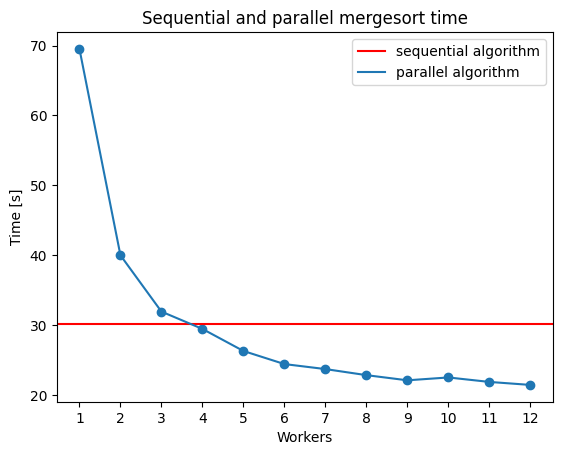

In [181]:
import matplotlib.pyplot as plt


plt.axhline(sequential_time, color="red", label="sequential algorithm")
plt.scatter(p_range, parallel_time)
plt.plot(p_range, parallel_time, label="parallel algorithm")
plt.xticks(p_range)

plt.xlabel("Workers")
plt.ylabel("Time [s]")
plt.title("Sequential and parallel mergesort time")
plt.legend()
plt.show()

## Part 8 - Compute Pi using Monte Carlo method (homework)
**Exercise:** Based on the previous example, create an actor-based system that can compute Pi using the Monte Carlo method. There should be one supervising actor and computing tasks/actors. As an output, we expect to have numbers approaching to 3.14


![monte-carlo](img/monte_carlo_pi_sma.png)

*Note* I should see something similar to this:

```
Current value of π is: 3.1413560033585224
Current value of π is: 3.1413457351746548
Current value of π is: 3.1413172115005907
Current value of π is: 3.1413644902634594
Current value of π is: 3.1413463306152707
Current value of π is: 3.1412993520518357
Current value of π is: 3.14122792002806
Current value of π is: 3.14125257767156
Current value of π is: 3.1412399868030354
Current value of π is: 3.14132
Current value of π is: 3.1413048336472067
Current value of π is: 3.1412723926380366
Current value of π is: 3.1413103117505994
Current value of π is: 3.141357113523027
Current value of π is: 3.1414312589618585
Current value of π is: 3.141471492704826

In [182]:
# implement here

@ray.remote
def points_generator(p, q, n):
    points = np.random.uniform([p, -1], [q, 1], size=(n, 2))
    count = 0

    for p in points:
        if np.linalg.norm(p) <= 1:
            count += 1
    
    return count

In [183]:
def estimate_pi(n, workers):
    size = 2 / workers
    plane_part_refs = []
    worker_points = int(np.round(n / workers))

    for i in range(workers):
        plane_part_refs.append(
            points_generator.remote(-1 + i * size, -1 + (i + 1) * size, worker_points)
        )
    
    total_inside = 0
    total_processed_points = 0

    while plane_part_refs:
        ready, plane_part_refs = ray.wait(plane_part_refs, num_returns=1)
        count = ray.get(ready[0])

        total_inside += count
        total_processed_points += worker_points

        current_pi = 4 * (total_inside / total_processed_points)
        print(f"Current value of π is: {current_pi}")
    
    return current_pi

In [184]:
n = 1000000
workers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
durations = []
time.sleep(2)

for w in workers:
    time_start = time.time()
    pi = estimate_pi(n, w)
    time_end = time.time()
    durations.append(time_end - time_start)

    print(f"PI estimation {w} workers time: {np.round(durations[-1], 2)} s\n")

Current value of π is: 3.141664
PI estimation 1 workers time: 1.53 s

Current value of π is: 3.138576
Current value of π is: 3.137544
PI estimation 2 workers time: 0.87 s

Current value of π is: 2.752070752070752
Current value of π is: 2.7506607506607508
Current value of π is: 3.142283142283142
PI estimation 3 workers time: 0.74 s

Current value of π is: 2.456448
Current value of π is: 2.45544
Current value of π is: 2.9130293333333332
Current value of π is: 3.141748
PI estimation 4 workers time: 0.64 s

Current value of π is: 2.24066
Current value of π is: 2.23672
Current value of π is: 2.70254
Current value of π is: 3.02015
Current value of π is: 3.142168
PI estimation 5 workers time: 0.55 s

Current value of π is: 2.0596998806002387
Current value of π is: 2.993046013907972
Current value of π is: 3.1416417167165664
Current value of π is: 2.870790258419483
Current value of π is: 2.9835972328055345
Current value of π is: 3.140465719068562
PI estimation 6 workers time: 0.51 s

Current va

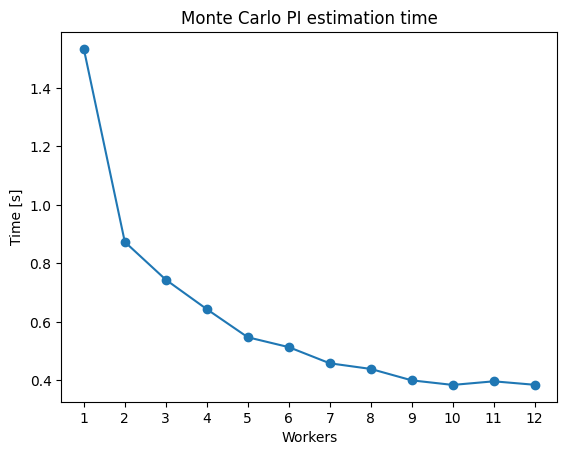

In [185]:
plt.scatter(workers, durations)
plt.plot(workers, durations)
plt.xticks(workers)

plt.xlabel("Workers")
plt.ylabel("Time [s]")
plt.title("Monte Carlo PI estimation time")
plt.show()

## Clean up  - Clean up the environemnt

**GOAL:** The goal of this exercise is to close the environment once you finish play with ray `ray.shutdown`.

In [186]:
ray.shutdown()